# Program - 

**Purpose**

Plot cn_map for TOA Sw_up in the NE Pacific region
1. CERES July climatology
2. TaiESM1 AMIP July climatology
3. TaiESM1 coupled July climatology
4. CERES July 2001
5. TaiESM1 hindcast Day 1
6. TaiESM1 hindcast Day 3

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 
February 2025

**Reference program:**



In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
import read_data_big as read_data    ## on my Mac

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Read data

## CERES - July climo & July 2001

In [73]:
datapath_ceres = "/lfs/home/yihsuanc/data/data.CERES/2001-2023/"
data_ceres = datapath_ceres + "CERES_EBAF_Ed4.2_Subset_200101-202312_TOA_CLD.nc"

# Load dataset (replace with actual file path or dataset)
ds_ceres = xr.open_dataset(data_ceres)

# Ensure time is in datetime format
ds_ceres['time'] = xr.decode_cf(ds_ceres)['time']

# Select all July data
ds_ceres_july = ds_ceres.sel(time=ds_ceres.time.dt.month == 7)

# Compute July climatology (mean over all years)
ds_ceres_july_climo = ds_ceres_july.mean(dim="time")

# Extract July 2001 data
ds_ceres_july_2001 = ds_ceres.sel(time=(ds_ceres.time.dt.year == 2001) & (ds_ceres.time.dt.month == 7))

## TaiESM1 - AMIP, July climo

In [75]:
datapath_taiesm1_amip = "/lfs/archive/CMIP6/TaiESM1/amip-hist/atmos/mon/r1i1p1f1/"
fnames = [
    "rsut_Amon_TaiESM1_amip-hist_r1i1p1f1_gn_197901-201012.nc",
    "rsut_Amon_TaiESM1_amip-hist_r1i1p1f1_gn_201101-201412.nc",
                 ]

fnames = [datapath_taiesm1_amip+file1 for file1 in fnames]
ds_taiesm1_amip = xr.open_mfdataset(fnames)

# Ensure time is in datetime format
ds_taiesm1_amip['time'] = xr.decode_cf(ds_taiesm1_amip)['time']

# Select all July data
ds_taiesm1_amip_july = ds_taiesm1_amip.sel(time=ds_taiesm1_amip.time.dt.month == 7)

# Compute July climatology (mean over all years)
ds_taiesm1_amip_climo = ds_taiesm1_amip_july.mean(dim="time")

# Extract July 2001 data
#ds_taiesm1_amip_july_2001 = ds_taiesm1_amip.sel(time=(ds_taiesm1_amip.time.dt.year == 2001) & (ds_taiesm1_amip.time.dt.month == 7))

## TaiESM1 - hist, July climo

In [77]:
datapath_taiesm1_hist = "/lfs/archive/CMIP6/TaiESM1/historical/atmos/mon/r1i1p1f1/"
fnames = datapath_taiesm1_hist+"rsut_Amon_TaiESM1_historical_r1i1p1f1_gn_185001-201412.nc"

ds_taiesm1_hist = xr.open_mfdataset(fnames)

# Ensure time is in datetime format
ds_taiesm1_hist['time'] = xr.decode_cf(ds_taiesm1_hist)['time']

# Select all July data
ds_taiesm1_hist_july = ds_taiesm1_hist.sel(time=ds_taiesm1_hist.time.dt.month == 7)

# Select July data from 1979 to 2014
ds_taiesm1_hist_july_1979_2014 = ds_taiesm1_hist.sel(time=(ds_taiesm1_hist.time.dt.year >= 1979) & 
                                     (ds_taiesm1_hist.time.dt.year <= 2014) & 
                                     (ds_taiesm1_hist.time.dt.month == 7))

# Compute July climatology (mean over all years)
ds_taiesm1_hist_climo = ds_taiesm1_hist_july.mean(dim="time")

# Compute July climatology (1979-2014)
ds_taiesm1_hist_36y = ds_taiesm1_hist_july_1979_2014.mean(dim="time")

## TaiESM1 - hindcast, July 2001

In [5]:
# TaiESM1 - hindcast, July 2001, day 1 ensemsble
ds_taiesm1_hcast_day1 = read_data.read_TaiESM1_hindcast_data(choice="TaiESM1_July01_30_2d_1hr", dayN_ensemble=1)
ds_taiesm1_hcast_day1_avg = ds_taiesm1_hcast_day1.mean(dim="time")

# TaiESM1 - hindcast, July 2001, day 3 ensemsble
ds_taiesm1_hcast_day3 = read_data.read_TaiESM1_hindcast_data(choice="TaiESM1_July01_30_2d_1hr", dayN_ensemble=3)
ds_taiesm1_hcast_day3_avg = ds_taiesm1_hcast_day3.mean(dim="time")

# Data processing

## Interpolation to the same lat/lon grid

In [78]:
#ds_ceres_july_climo  # lon: 360, lat: 180
#ds_ceres_july_2001  # lon: 360, lat: 180, time: 1

ds_ceres_july_climo_taiesm_grid = ds_ceres_july_climo.interp_like(ds_taiesm1_amip_climo, kwargs={"fill_value": "extrapolate"})
ds_ceres_july_2001_taiesm_grid = ds_ceres_july_2001.interp_like(ds_taiesm1_amip_climo, kwargs={"fill_value": "extrapolate"})

## Take difference between CERES and TaiESM1

In [84]:
varname_ceres = "toa_sw_all_mon"
varname_hist = "rsut"
varname_hcast = "FSUTOA"

# July climatology, CERES - hist_36y & AMIP
da_JulyClimo_hist165yMceres = - ds_ceres_july_climo_taiesm_grid[varname_ceres] + ds_taiesm1_hist_climo[varname_hist]
da_JulyClimo_hist36yMceres  = - ds_ceres_july_climo_taiesm_grid[varname_ceres] + ds_taiesm1_hist_36y[varname_hist]
da_JulyClimo_amipMceres     = - ds_ceres_july_climo_taiesm_grid[varname_ceres] + ds_taiesm1_amip_climo[varname_hist]

# July 2001, CERES - hindcast day 1 & day 3
da_July2001_hcastD1Mceres  = - ds_ceres_july_2001_taiesm_grid[varname_ceres] + ds_taiesm1_hcast_day1_avg[varname_hcast]
da_July2001_hcastD3Mceres  = - ds_ceres_july_2001_taiesm_grid[varname_ceres] + ds_taiesm1_hcast_day3_avg[varname_hcast]

### July climatology

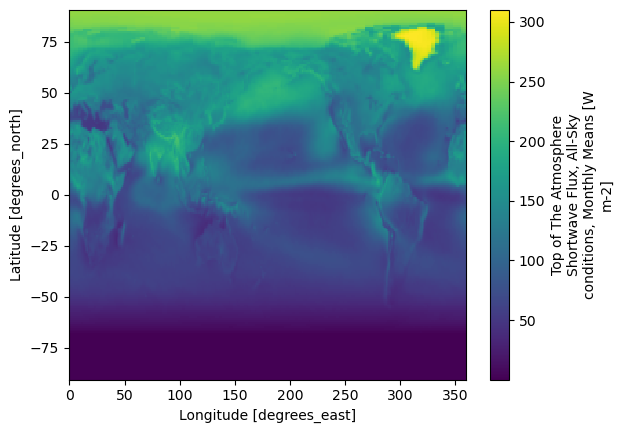

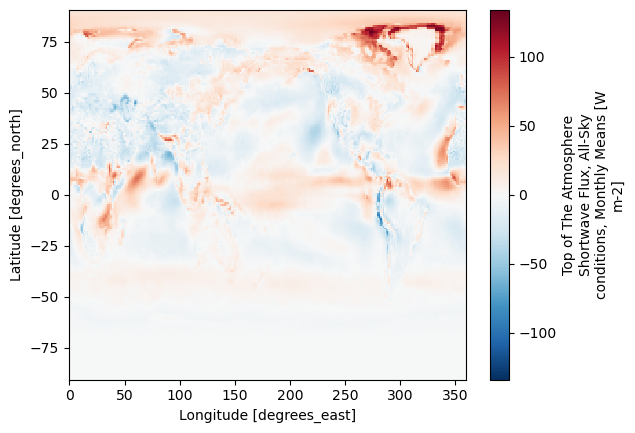

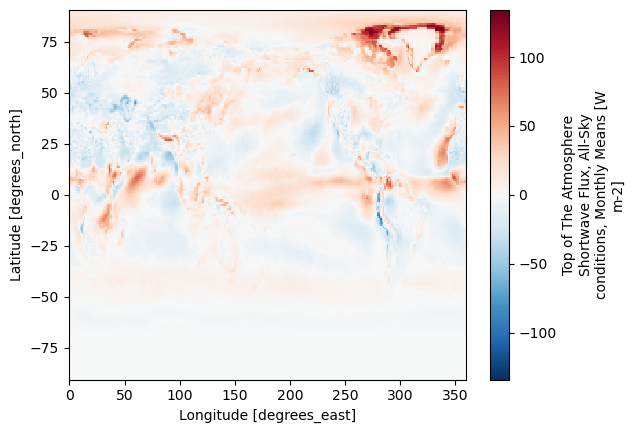

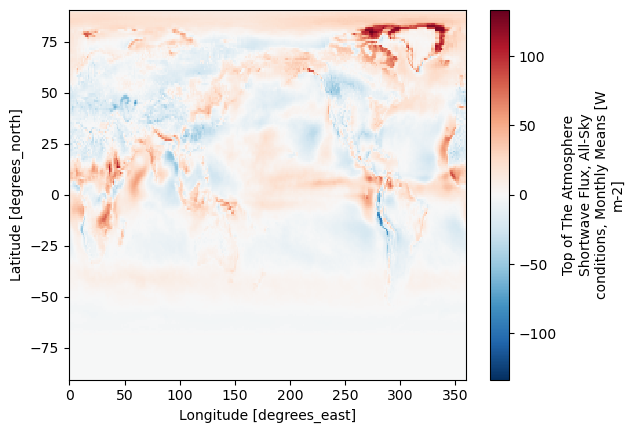

In [85]:
ds_ceres_july_climo_taiesm_grid[varname_ceres].plot() ; plt.show()
da_JulyClimo_hist165yMceres.plot() ; plt.show()
da_JulyClimo_hist36yMceres.plot() ; plt.show()
da_JulyClimo_amipMceres.plot() ; plt.show()

### July 2001

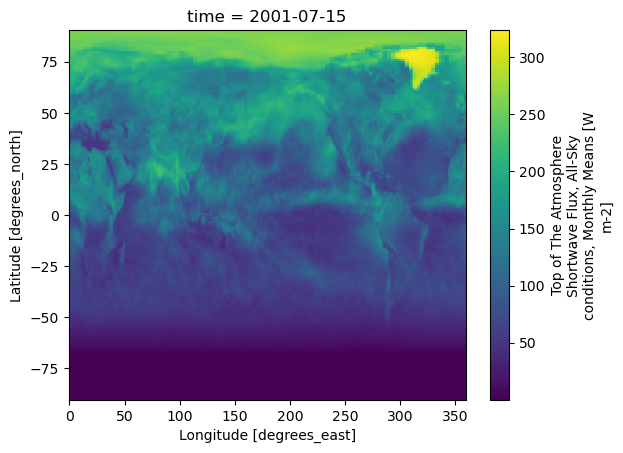

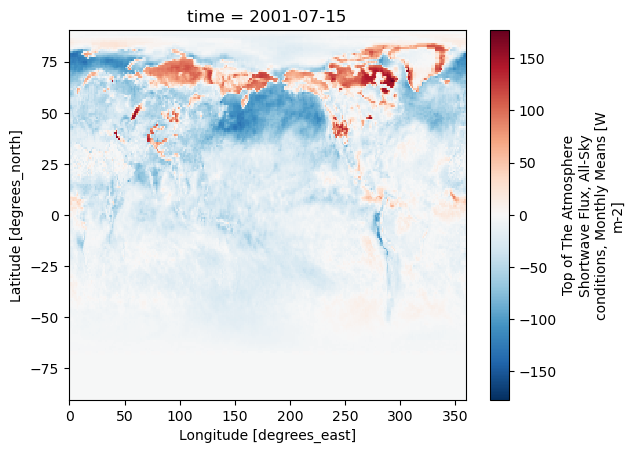

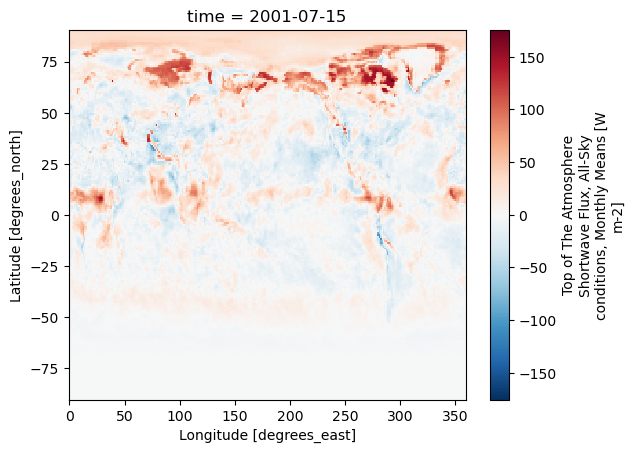

In [86]:
ds_ceres_july_2001_taiesm_grid[varname_ceres].plot() ; plt.show()
da_July2001_hcastD1Mceres.plot() ; plt.show()
da_July2001_hcastD3Mceres.plot() ; plt.show()

In [23]:
#yhc.lib("fdef")   # check out yhc library